In [1]:
# LOAD Packages (copied from initial training script)
import numpy as np
from collections import namedtuple, OrderedDict
import sys
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/')
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/utils/')
from utils.parse_yaml import ParseYAML
from plot_sheep_tests import TestedSheep
from plot_NDLAr_sheep_tests import TestedSheepNDLAr

import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import os
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import json
import h5py
import glob
import os
import argparse
import csv
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.axes import Axes
from scipy.stats import linregress, skew, kurtosis


Less than 0.35 visible energy fraction: 11
Events with less than 0.4 VE fraction: [[ 501.]
 [ 524.]
 [ 898.]
 [1010.]
 [1961.]
 [3114.]
 [3329.]
 [3825.]
 [4382.]
 [4934.]
 [4986.]]


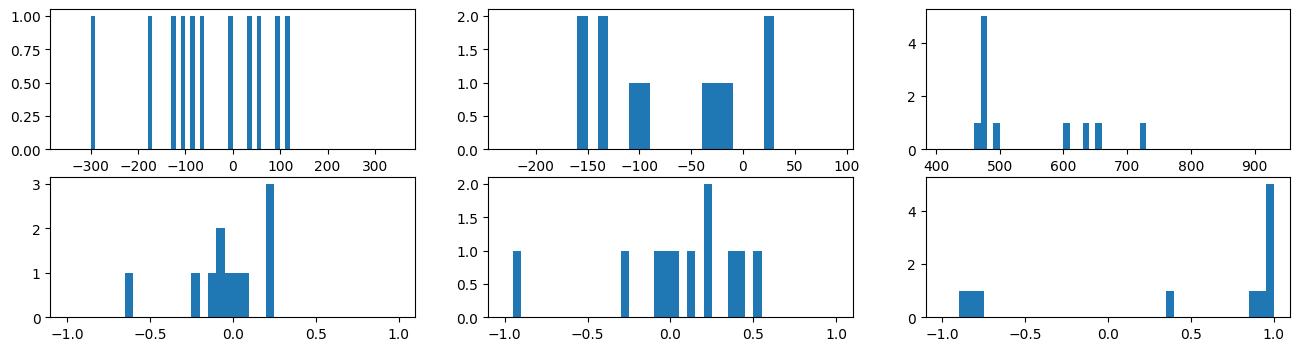

In [2]:
test_dir = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/'
test_config = 'test_weighted_mse_lin'
train_config = 'weighted_mse_lin'
run_num = 'WeightedMSE-LinearEnergyScale-50kSample-NDLArTest-HDF5-Test2'
ckpt_file = 'ckpt_epoch_93_iters_14664_best.tar'
csv_file = test_dir+test_config+'/'+run_num+'/logs/WeightedMSE-LinearEnergyScale-50kSample-NDLArTest-HDF5-Test2_test_weighted_mse_lin_ckpt_epoch_93_iters_14664_best_NUElog_threshold.csv'
idxs = []
labels = []
preds = []
ve = []
ve_frac = []
mg_frac = []
oob_frac = []
start_position = []
rotation_matrix = []
with open(csv_file, 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        #print(row)
        idxs.append(str(row['idx']))
        labels.append(float(row['label']))
        preds.append(float(row['prediction']))
        ve.append(float(row['visible_energy']))
        ve_frac.append(float(row['ve_frac']))
        mg_frac.append(float(row['mg_frac']))
        oob_frac.append(float(row['oob_frac']))
        start_position.append(str(row['start_position']))
        rotation_matrix.append(str(row['rotation_matrix']))

#print(idxs)
idxs = np.array([np.fromstring(i.strip('[]'), sep=' ') for i in idxs])
#print(idxs)
labels = np.array(labels)
preds = np.array(preds)
ve = np.array(ve)
ve_frac = np.array(ve_frac)
mg_frac = np.array(mg_frac)
oob_frac = np.array(oob_frac)
start_position = np.array([np.fromstring(s.strip('[]'), sep=' ') for s in start_position])
rotation_matrix = np.array([
    np.fromstring(r.replace('\n', ' ').replace('[', '').replace(']', ''), sep=' ').reshape(3, 3)
    for r in rotation_matrix
])
#print(rotation_matrix)
x = start_position[:,0]
y = start_position[:,1]
z = start_position[:,2]

x_dir = rotation_matrix[:,2,0]
y_dir = rotation_matrix[:,2,1]
z_dir = rotation_matrix[:,2,2]
#### OOB Frac vs. MG Frac by visible energy fraction bin
fig, ax = plt.subplots(2,3,figsize=(16,4))

missing_frac_bins = np.linspace(0, 1, 20 + 1)
ve_frac_mask = ve_frac < 0.35
print("Less than 0.35 visible energy fraction:",sum(ve_frac_mask))
print("Events with less than 0.4 VE fraction:", idxs[ve_frac_mask])
#ax.scatter(x[oob_frac_mask], y[oob_frac_mask], z[oob_frac_mask])
x_bins=np.linspace(-350,350,71)
y_bins=np.linspace(-230,90,33)
z_bins=np.linspace(410,930,53)
x = x[ve_frac_mask]
y = y[ve_frac_mask]
z = z[ve_frac_mask]

x_dir = x_dir[ve_frac_mask]
y_dir = y_dir[ve_frac_mask]
z_dir = z_dir[ve_frac_mask]
dir_bins = np.linspace(-1,1, 40+1)
"""x_mask = abs(x) < 297
print("X < 297 and X > -297:",sum(x_mask))
x = x[x_mask]
y = y[x_mask]
z = z[x_mask]
y_mask = (y > -166) & (y < 32)
print("Y > -166 and Y < 32:",sum(y_mask))
x = x[y_mask]
y = y[y_mask]
z = z[y_mask]
z_mask = (z > 468) & (z < 763)"""
#print("Z > 468 and Z < 763:",sum(z_mask))
ax[0,0].hist(x, bins=x_bins)
ax[0,1].hist(y, bins=y_bins)
ax[0,2].hist(z, bins=z_bins)
ax[1,0].hist(x_dir, bins=dir_bins)
ax[1,1].hist(y_dir, bins=dir_bins)
ax[1,2].hist(z_dir, bins=dir_bins)
#h = plt.hist2d(z,oob_frac,bins=(z_bins,missing_frac_bins),cmap='magma_r',cmin=1)
#im = h[3]
#plt.xlabel("Shower Starting Z Location")
#plt.ylabel("Uncontained Energy Fraction")
#cbar = fig.colorbar(im, ax=ax,orientation='vertical', fraction=0.02, pad=0.02)
#cbar.set_label('Events', fontsize=12)
plt.show()

Labels: 13472.332


(-230.0, 90.0)

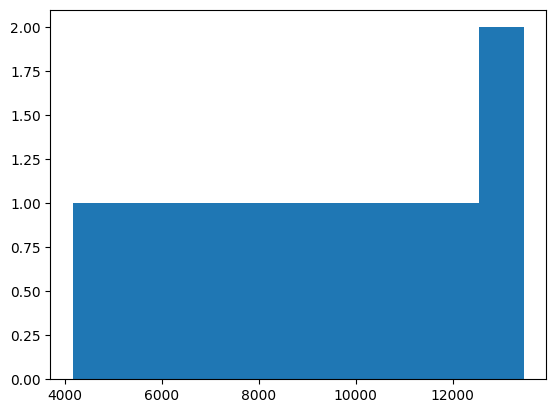

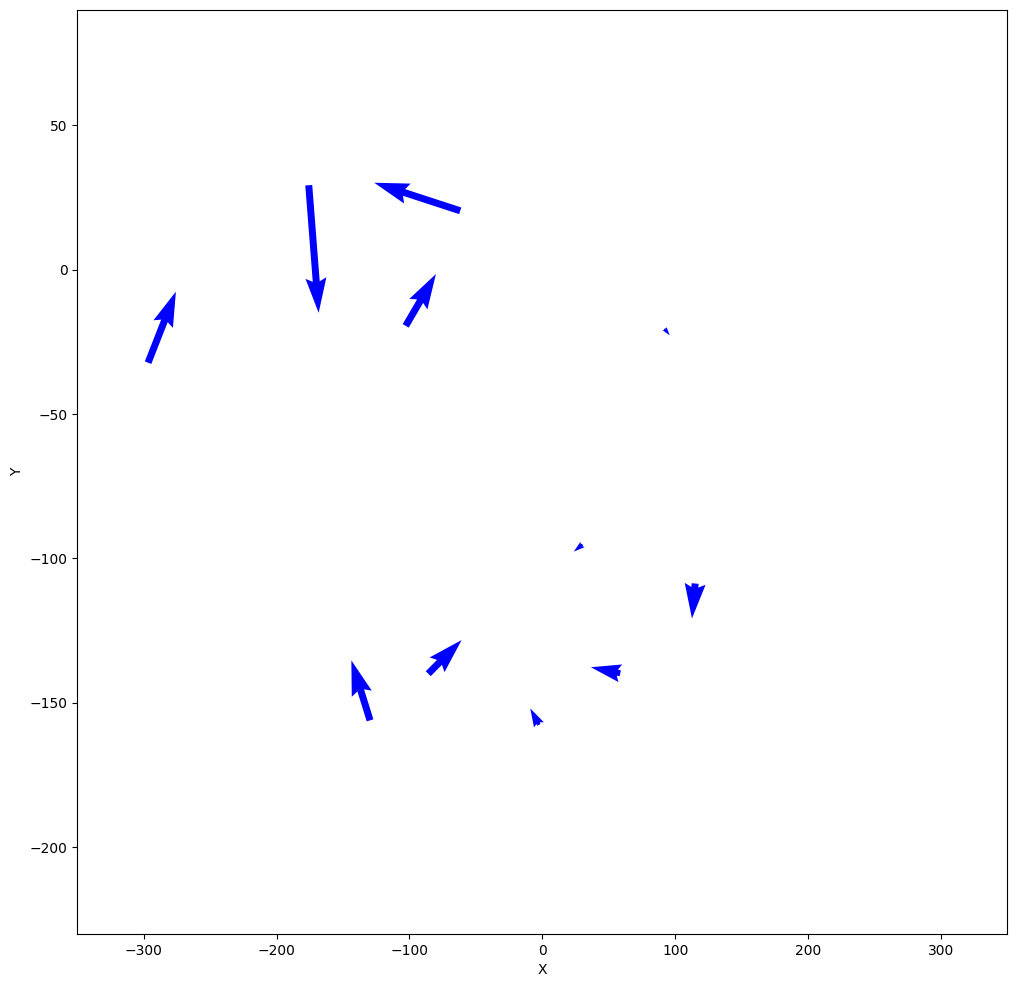

In [3]:
idx=4
plt.hist(labels[ve_frac_mask])
print('Labels:', labels[ve_frac_mask][idx])
fig = plt.figure(figsize=(12,12))
#ax = fig.add_subplot(projection='3d')
ax = fig.add_subplot()
#ax.quiver(z[idx], x[idx], y[idx], z_dir[idx], x_dir[idx], y_dir[idx], 
#          color='blue', arrow_length_ratio=0.3, normalize=True)
ax.quiver(x, y, x_dir, y_dir, 
          color='blue')
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_xlim(-350, 350)
ax.set_ylim(-230, 90)
#ax.set_zlabel("Y")

In [4]:
test_dir = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/'
all_config = 'test'
all_train_config = 'default'
all_results_dir = './outputs'
all_num_energy_bins = '30'
all_num_ve_frac_bins = '10'

version = 'Weighted MSE Loss | E/1000 Target'
test_config = 'test_weighted_mse_lin'
train_config = 'weighted_mse_lin'
#run_num = 'WeightedMSE-LinearEnergyScale-98kSample-2x2Photons-PhotonStartInFV-3920bs'#
run_num='WeightedMSE-LinearEnergyScale-50kSample-NDLArTest-HDF5-Test2'
ckpt_filestring = 'ckpt_epoch_93_iters_14664_best'
ckpt_file = ckpt_filestring+'.tar'
csv_file = test_dir+test_config+'/'+run_num+'/logs/'+run_num+'_'+test_config+'_'+ckpt_filestring+'_NUElog_threshold.csv'

sys.argv = ['plot_NDLAr_sheep_tests.py', '--csv_file', csv_file, '--version', version, '--config', test_config, '--train_config', train_config, '--results_dir', './outputs', '--run_num', run_num, '--checkpoint_file', ckpt_file, '--num_energy_bins', all_num_energy_bins, '--num_ve_frac_bins', all_num_ve_frac_bins]

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=30, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

ndlarl1log = TestedSheepNDLAr(args)
ndlarl1log.run()

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:10729: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:10743: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:10749: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


IQR Value: 0.0749109772308183
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred CB: chi2/ndf = 0.06 / 20 = 0.00
Vis CB:  chi2/ndf = 0.02 / 22 = 0.00
IQR Value: 0.1374016573296267
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred CB: chi2/ndf = 0.07 / 34 = 0.00
Vis CB:  chi2/ndf = 0.02 / 23 = 0.00
Pred converged: True
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred converged: True
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred converged: True


/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_NDLAr_sheep_tests.py:837: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ebins[i]:.0f}-{self.ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {fit_params_pred[0]:.2f} \nStd Dev: {fit_params_pred[1]:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_NDLAr_sheep_tests.py:838: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.4, f"Mean: {cb_params_vis[2]:.2f} \nStd Dev: {cb_params_vis[3]:.2f}\nα: {cb_params_vis[0]:.2f}\nn: {cb_params_vis[1]:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(

Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred converged: False
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred converged: True
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred converged: True
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred converged: True
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred converged: True
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred converged: True
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred converged: True
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred converged: True
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred converged: True
Vis converged:  True — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Pred converged: False
Vis converged:  True — CONVE

/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_NDLAr_sheep_tests.py:27: RuntimeWarning: divide by zero encountered in divide
  return amplitude * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_NDLAr_sheep_tests.py:887: OptimizeWarning: Covariance of the parameters could not be estimated
  true_pred_params, true_pred_covariance = curve_fit(gaussian, bin_centers_true_pred, (hist_counts_true_pred/num_events_per_ve_frac_bin), p0=initial_guesses_true_pred)
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_NDLAr_sheep_tests.py:900: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ve_frac_bins[i]:.2f}-{self.ve_frac_bins[i+1]:.2f} \n{frac_events_per_ve_frac_bin:.2f}% of Events\nMean: {true_pred_params[

In [ ]:
test_dir = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/'
all_config = 'test'
all_train_config = 'default'
all_results_dir = './outputs'
all_num_energy_bins = 20
all_num_ve_frac_bins = 10

mselin_version = 'MSE Loss | E/1000 Target'
mselin_test_config = 'test_mse_lin'
mselin_train_config = 'mse_lin'
mselin_run_num = 'MSELOSS-LinEnergyScale-250kSample-ValidTest'
mselin_ckpt_file = 'ckpt_epoch_137_iters_8832_best.tar'
mselin_csv_file = test_dir+mselin_test_config+'/'+mselin_run_num+'/logs/MSELOSS-LinEnergyScale-250kSample-ValidTest_test_mse_lin_ckpt_epoch_137_iters_8832_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', mselin_csv_file, '--version', mselin_version, '--config', mselin_test_config, '--train_config', mselin_train_config, '--results_dir', './outputs', '--run_num', mselin_run_num, '--checkpoint_file', mselin_ckpt_file]

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

mse_lin = TestedSheep(args)
mse_lin.run()

In [3]:
test_dir = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/'
mselog_version = 'MSE Loss | log(E) Target'
mselog_test_config = 'test_mse_log'
mselog_train_config = 'mse_log'
mselog_run_num = 'MSELOSS-LogEnergyScale-250kSample-ValidTest'
mselog_ckpt_file = 'ckpt_epoch_148_iters_9536_best.tar'
mselog_csv_file = test_dir+mselog_test_config+'/'+mselog_run_num+'/logs/MSELOSS-LogEnergyScale-250kSample-ValidTest_test_mse_log_ckpt_epoch_148_iters_9536_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', mselog_csv_file, '--version', mselog_version, '--config', mselog_test_config, '--train_config', mselog_train_config, '--results_dir', './outputs', '--run_num', mselog_run_num, '--checkpoint_file', mselog_ckpt_file,'--num_energy_bins', '20']

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

mse_log = TestedSheep(args)
mse_log.run()

NameError: name 'sys' is not defined

In [4]:
test_dir = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/'
l1lin_version = 'L1 Loss | E/1000 Target'
l1lin_run_num = 'L1LOSS-LinEnergyScale-250kSample-ValidTest'
l1lin_config = 'test_l1_lin'
l1lin_train_config = 'l1_lin'
l1lin_ckpt_file = 'ckpt_epoch_134_iters_8640_best.tar'
l1lin_csv_file = test_dir+l1lin_config+'/'+l1lin_run_num+'/logs/L1LOSS-LinEnergyScale-250kSample-ValidTest_test_l1_lin_ckpt_epoch_134_iters_8640_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', l1lin_csv_file, '--version', l1lin_version, '--config', l1lin_config, '--train_config', l1lin_train_config, '--results_dir', './outputs', '--run_num', l1lin_run_num, '--checkpoint_file', l1lin_ckpt_file,'--num_energy_bins', '20']

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

l1_lin = TestedSheep(args)
l1_lin.run()

/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:301: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ebins[i]:.0f}-{self.ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {pred_res_skew:.2f}\nKurtosis: {pred_res_kurtosis:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:364: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ve_frac_bins[i]:.2f}-{self.ve_frac_bins[i+1]:.2f} \n{frac_events_per_ve_frac_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd 

In [5]:
test_dir = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/'
l1log_version = 'L1 Loss | log(E) Target'
l1log_run_num = 'L1LOSS-LogEnergyScale-250kSample-ValidTest'
l1log_config = 'test_l1_log'
l1log_train_config = 'l1_log'
l1log_ckpt_file = 'ckpt_epoch_149_iters_9600_best.tar'
l1log_csv_file = test_dir+l1log_config+'/'+l1log_run_num+'/logs/L1LOSS-LogEnergyScale-250kSample-ValidTest_test_l1_log_ckpt_epoch_149_iters_9600_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', l1log_csv_file, '--version', l1log_version, '--config', l1log_config, '--train_config', l1log_train_config, '--results_dir', './outputs', '--run_num', l1log_run_num, '--checkpoint_file', l1log_ckpt_file,'--num_energy_bins', '20']

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

l1_log = TestedSheep(args)
l1_log.run()

/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:301: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ebins[i]:.0f}-{self.ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {pred_res_skew:.2f}\nKurtosis: {pred_res_kurtosis:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:364: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ve_frac_bins[i]:.2f}-{self.ve_frac_bins[i+1]:.2f} \n{frac_events_per_ve_frac_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd 

In [3]:
huberlin_config = 'test_huber_lin'
huberlin_train_config = 'huber_lin'
huberlin_version = 'Huber Loss | E/1000 Target'
huberlin_run_num = 'HuberLOSS-LinEnergyScale-250kSample-ValidTest'
huberlin_ckpt_file = 'ckpt_epoch_140_iters_9024_best.tar'
huberlin_csv_file = test_dir+huberlin_config+'/'+huberlin_run_num+'/logs/HuberLOSS-LinEnergyScale-250kSample-ValidTest_test_huber_lin_ckpt_epoch_140_iters_9024_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', huberlin_csv_file, '--version', huberlin_version, '--config', huberlin_config, '--train_config', huberlin_train_config, '--results_dir', './outputs', '--run_num', huberlin_run_num, '--checkpoint_file', huberlin_ckpt_file]

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

huber_lin = TestedSheep(args)
huber_lin.run()

/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:301: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ebins[i]:.0f}-{self.ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {pred_res_skew:.2f}\nKurtosis: {pred_res_kurtosis:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:364: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ve_frac_bins[i]:.2f}-{self.ve_frac_bins[i+1]:.2f} \n{frac_events_per_ve_frac_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd 

In [2]:
test_dir = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/'
huberlog_config = 'test_huber_log'
huberlog_train_config = 'huber_log'
huberlog_version = 'Huber Loss | log(E) Target'
huberlog_run_num = 'HuberLOSS-LogEnergyScale-250kSample-ValidTest'
huberlog_ckpt_file = 'ckpt_epoch_148_iters_9536_best.tar'
huberlog_csv_file = test_dir+huberlog_config+'/'+huberlog_run_num+'/logs/HuberLOSS-LogEnergyScale-250kSample-ValidTest_test_huber_log_ckpt_epoch_148_iters_9536_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', huberlog_csv_file, '--version', huberlog_version, '--config', huberlog_config, '--train_config', huberlog_train_config, '--results_dir', './outputs', '--run_num', huberlog_run_num, '--checkpoint_file', huberlog_ckpt_file]

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

huber_log = TestedSheep(args)
huber_log.run()

/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:301: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ebins[i]:.0f}-{self.ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {pred_res_skew:.2f}\nKurtosis: {pred_res_kurtosis:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:364: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ve_frac_bins[i]:.2f}-{self.ve_frac_bins[i+1]:.2f} \n{frac_events_per_ve_frac_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd 

In [8]:
'''mselinLRinc_version = 'MSE Loss | E/1000 Target | LR Scheduler'
mselinLRinc_run_num = 'ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-LR_SCHEDULE_20_0p0001'
mselinLRinc_ckpt_file = 'ckpt_epoch_90_iters_2275_best.tar'
mselinLRinc_csv_file = test_dir+mselinLRinc_run_num+'/logs/ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-LR_SCHEDULE_20_0p0001_test_ckpt_epoch_90_iters_2275_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', mselinLRinc_csv_file, '--version', mselinLRinc_version, '--config', 'test', '--train_config', 'default', '--results_dir', './outputs', '--run_num', mselinLRinc_run_num, '--checkpoint_file', mselinLRinc_ckpt_file]

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

mse_linLRinc = TestedSheep(args)
mse_linLRinc.run()'''

'mselinLRinc_version = \'MSE Loss | E/1000 Target | LR Scheduler\'\nmselinLRinc_run_num = \'ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-LR_SCHEDULE_20_0p0001\'\nmselinLRinc_ckpt_file = \'ckpt_epoch_90_iters_2275_best.tar\'\nmselinLRinc_csv_file = test_dir+mselinLRinc_run_num+\'/logs/ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-LR_SCHEDULE_20_0p0001_test_ckpt_epoch_90_iters_2275_best_log.csv\'\n\nsys.argv = [\'plot_sheep_tests.py\', \'--csv_file\', mselinLRinc_csv_file, \'--version\', mselinLRinc_version, \'--config\', \'test\', \'--train_config\', \'default\', \'--results_dir\', \'./outputs\', \'--run_num\', mselinLRinc_run_num, \'--checkpoint_file\', mselinLRinc_ckpt_file]\n\nparser = argparse.ArgumentParser()\nparser.add_argument("--csv_file", default=\'test_results.csv\', type=str, help=\'csv file with test results\')\nparser.add_argument("--version", default=\'MSE Loss / E/1000 Target\', type=str, help=\'csv file with test results\')\nparser.add_argument("--config", defa

In [8]:
tested_sheeps = [mse_lin, mse_log, l1_lin, l1_log, huber_lin, huber_log]
#tested_sheeps_BEST = [mse_lin_BEST, mse_log_BEST, l1_lin_BEST, l1_log_BEST, huber_lin_BEST, huber_log_BEST]
num_sheeps = len(tested_sheeps)
num_ebins = int(tested_sheeps[0].num_energy_bins)
ebins= tested_sheeps[0].ebins
num_ve_frac_bins = int(tested_sheeps[0].num_ve_frac_bins)
ve_frac_bins = tested_sheeps[0].ve_frac_bins

labels = [sheep.version for sheep in tested_sheeps]

true_vs_pred_res_slopes = [sheep.true_vs_pred_res_slope for sheep in tested_sheeps]
true_vs_pred_res_intercepts = [sheep.true_vs_pred_res_intercept for sheep in tested_sheeps]
true_vs_pred_res_r2 = [sheep.true_vs_pred_res_r2 for sheep in tested_sheeps]

pred_total_res_gauss_fit_means = [sheep.pred_total_res_gauss_fit_mean for sheep in tested_sheeps]
pred_total_res_gauss_fit_stds = [sheep.pred_total_res_gauss_fit_std for sheep in tested_sheeps]
pred_res_total_skews = [sheep.pred_res_total_skew for sheep in tested_sheeps]
pred_res_total_kurtoses = [sheep.pred_res_total_kurtosis for sheep in tested_sheeps]

# By energy /ve frac bin

true_vs_pred_res_slopes_by_ve_frac_bins = np.zeros((num_sheeps, num_ve_frac_bins))
true_vs_pred_res_intercepts_by_ve_frac_bins = np.zeros((num_sheeps, num_ve_frac_bins))
true_vs_pred_res_r2_by_ve_frac_bins = np.zeros((num_sheeps, num_ve_frac_bins))

for i in range(num_sheeps):
    true_vs_pred_res_slopes_by_ve_frac_bins[i,:] = tested_sheeps[i].true_vs_pred_res_slope_by_ve_frac_bin
    true_vs_pred_res_intercepts_by_ve_frac_bins[i,:] = tested_sheeps[i].true_vs_pred_res_intercept_by_ve_frac_bin
    true_vs_pred_res_r2_by_ve_frac_bins[i,:] = tested_sheeps[i].true_vs_pred_res_r2_by_ve_frac_bin
#print(true_vs_pred_res_slopes_by_ve_frac_bins)

pred_total_res_gauss_fit_means_by_ebins = np.zeros((num_sheeps, num_ebins))
pred_total_res_gauss_fit_stds_by_ebins = np.zeros((num_sheeps, num_ebins))
pred_res_total_skews_by_ebins = np.zeros((num_sheeps, num_ebins))
pred_res_total_kurtoses_by_ebins = np.zeros((num_sheeps, num_ebins))

for i in range(num_sheeps):
    pred_total_res_gauss_fit_means_by_ebins[i,:] = tested_sheeps[i].pred_res_gauss_fit_mean_by_ebin
    pred_total_res_gauss_fit_stds_by_ebins[i,:] = tested_sheeps[i].pred_res_gauss_fit_std_by_ebin
    pred_res_total_skews_by_ebins[i,:] = tested_sheeps[i].pred_res_skew_by_ebin
    pred_res_total_kurtoses_by_ebins[i,:] = tested_sheeps[i].pred_res_kurtosis_by_ebin


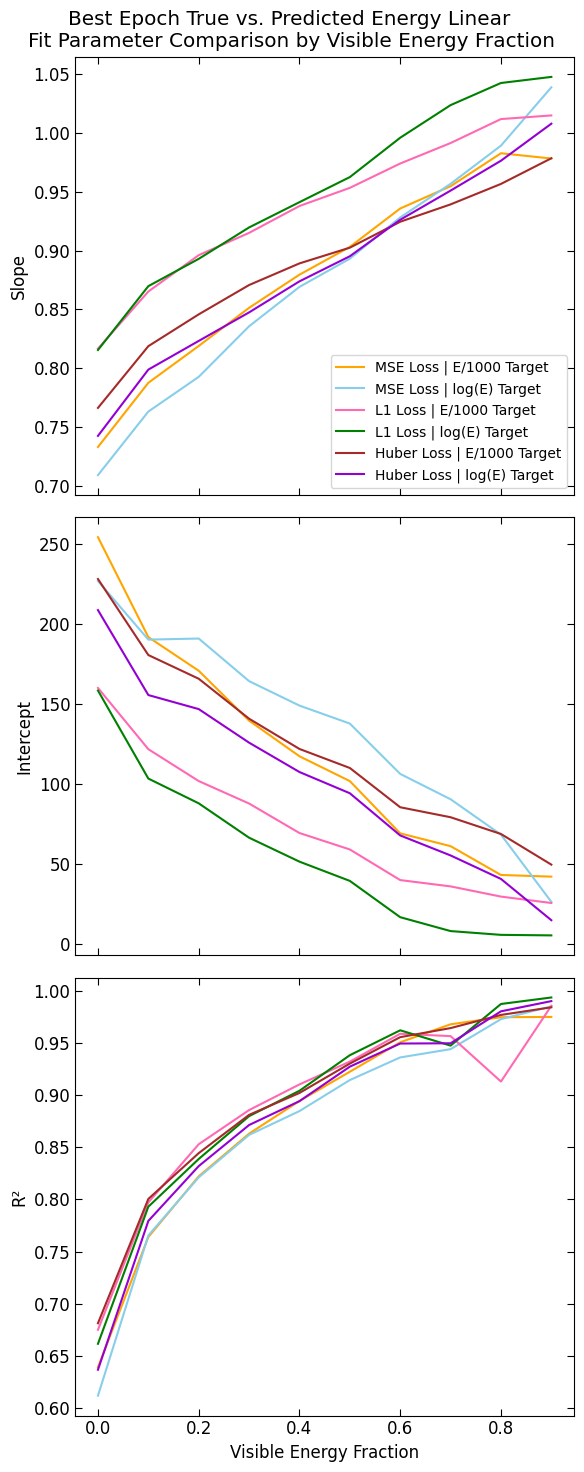

In [9]:
colors = ['orange', 'skyblue', 'hotpink', 'green', 'brown', 'darkviolet', 'dimgrey']
fig, ax = plt.subplots(3,1,figsize=(6,15), sharex=True)

for i in range(num_sheeps):
    ax[0].plot(ve_frac_bins[:-1],true_vs_pred_res_slopes_by_ve_frac_bins[i], color=colors[i], label=labels[i])
    ax[1].plot(ve_frac_bins[:-1],true_vs_pred_res_intercepts_by_ve_frac_bins[i], color=colors[i], label=labels[i])
    ax[2].plot(ve_frac_bins[:-1],true_vs_pred_res_r2_by_ve_frac_bins[i], color=colors[i], label=labels[i])

ax[0].set_ylabel('Slope')
ax[2].set_xlabel('Visible Energy Fraction')

ax[1].set_ylabel('Intercept')
ax[0].legend(fontsize=10)

ax[2].set_ylabel('R²')
fig.suptitle('Best Epoch True vs. Predicted Energy Linear \nFit Parameter Comparison by Visible Energy Fraction')

fig.tight_layout()
#plt.show()
plt.savefig('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/test/comparisons/linear_fit_comp_test_by_energy_bin_250ksample_150epochs_bestepoch.png')

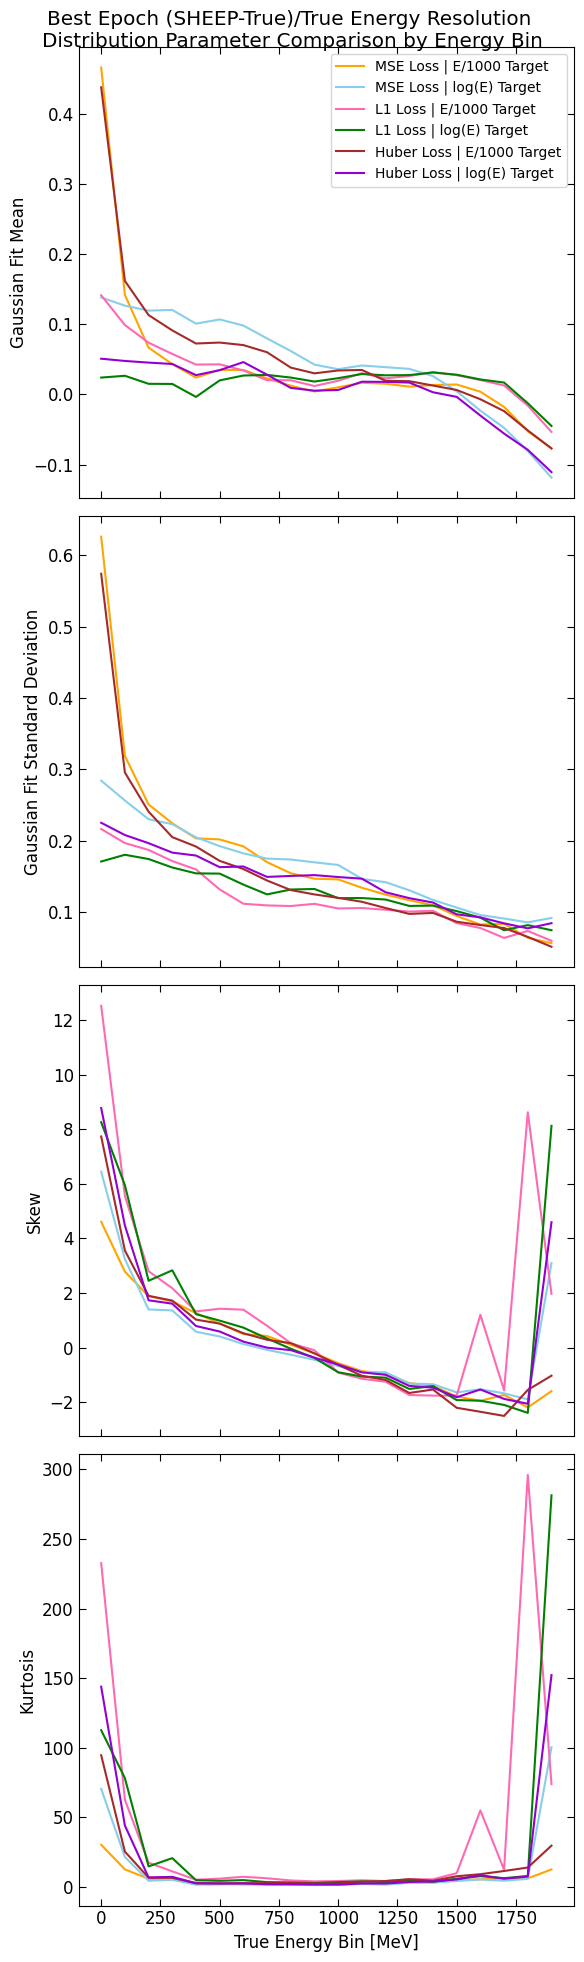

In [10]:
fig, ax = plt.subplots(4,1,figsize=(6,20), sharex=True)

for i in range(num_sheeps):
    ax[0].plot(ebins[:-1],pred_total_res_gauss_fit_means_by_ebins[i], color=colors[i], label=labels[i])
    ax[1].plot(ebins[:-1],pred_total_res_gauss_fit_stds_by_ebins[i], color=colors[i], label=labels[i])
    ax[2].plot(ebins[:-1],pred_res_total_skews_by_ebins[i], color=colors[i], label=labels[i])
    ax[3].plot(ebins[:-1],pred_res_total_kurtoses_by_ebins[i], color=colors[i], label=labels[i])


ax[0].legend(fontsize=10)

#ax[0].scatter(labels, pred_total_res_gauss_fit_means)
ax[0].set_ylabel('Gaussian Fit Mean')
ax[3].set_xlabel('True Energy Bin [MeV]')

#ax[1].scatter(labels,pred_total_res_gauss_fit_stds)
ax[1].set_ylabel('Gaussian Fit Standard Deviation')

#ax[2].scatter(labels,pred_res_total_skews)
ax[2].set_ylabel('Skew')

#ax[3].scatter(labels,pred_res_total_kurtoses)
ax[3].set_ylabel('Kurtosis')
fig.suptitle('Best Epoch (SHEEP-True)/True Energy Resolution \nDistribution Parameter Comparison by Energy Bin')

fig.tight_layout()
#plt.show()
plt.savefig('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/test/comparisons/pred_gaus_fit_comp_test_by_energy_bin_250ksample_150epochs_bestepoch.png')

/tmp/ipykernel_725022/2755341227.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(labels, rotation=30, ha='right')


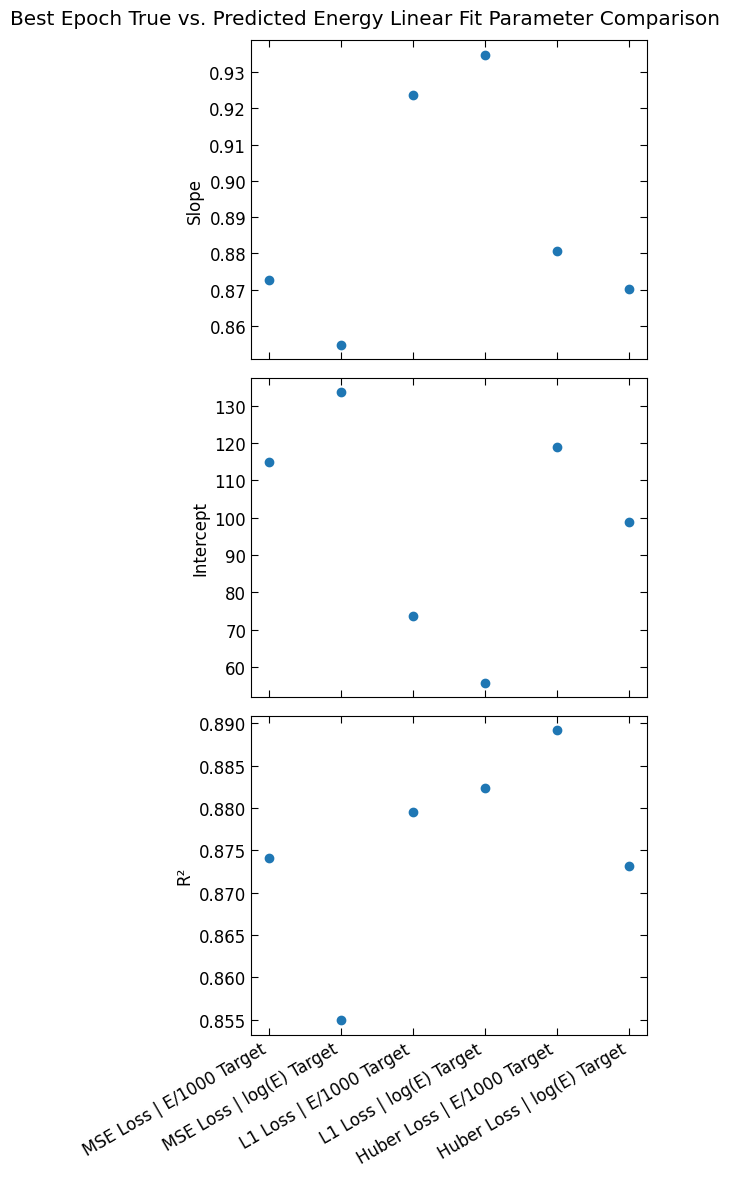

In [11]:
# Compare Res Slopes and intercepts and r^2
fig, ax = plt.subplots(3,1,figsize=(6,12), sharex=True)
ax[0].scatter(labels, true_vs_pred_res_slopes)
ax[0].set_ylabel('Slope')
#ax[2].set_xlabel('SHEEP Model Version')
ax[2].set_xticklabels(labels, rotation=30, ha='right') 

ax[1].scatter(labels,true_vs_pred_res_intercepts)
ax[1].set_ylabel('Intercept')

ax[2].scatter(labels,true_vs_pred_res_r2)
ax[2].set_ylabel('R²')
fig.suptitle('Best Epoch True vs. Predicted Energy Linear Fit Parameter Comparison')
fig.tight_layout()
#plt.show()
plt.savefig('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/test/comparisons/linear_fit_comp_test_250ksample_150epochs_bestepoch.png')


/tmp/ipykernel_725022/3685929459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(labels, rotation=30, ha='right')


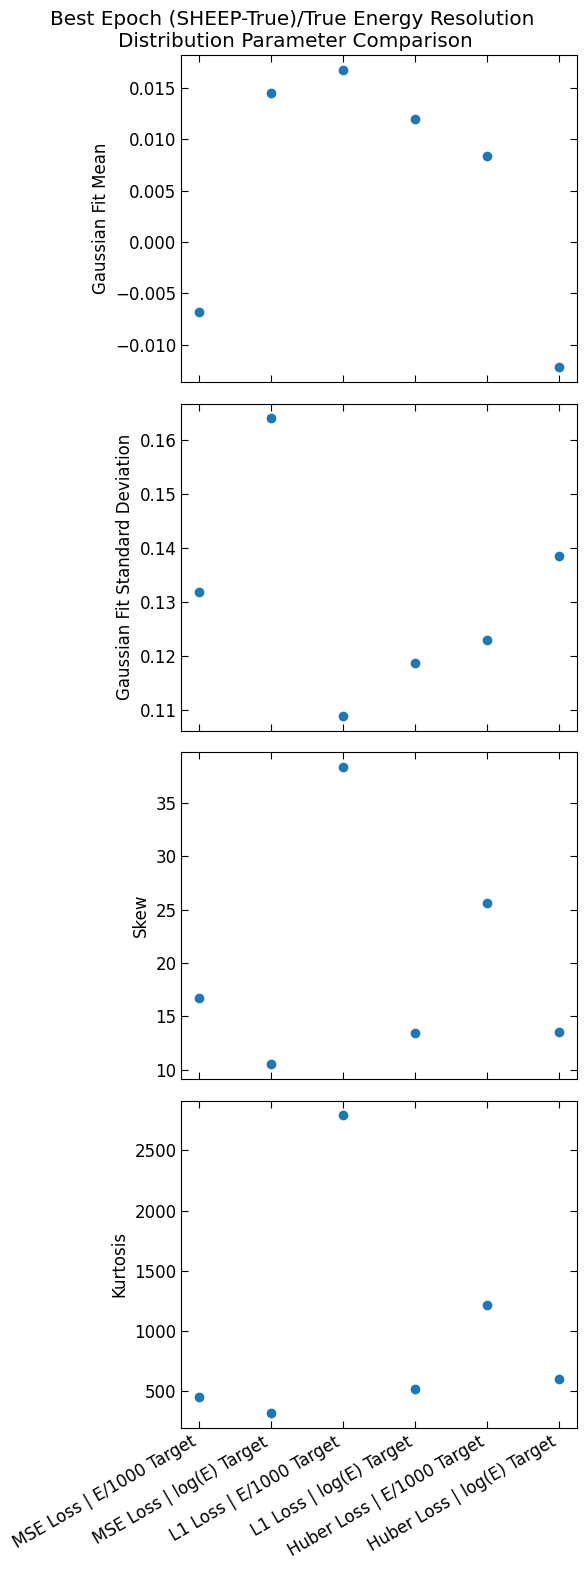

In [12]:
# Compare Gaus Fit and Skew and Kurtosis
fig, ax = plt.subplots(4,1,figsize=(6,16), sharex=True)
ax[0].scatter(labels, pred_total_res_gauss_fit_means)
ax[0].set_ylabel('Gaussian Fit Mean')
#ax[2].set_xlabel('SHEEP Model Version')
ax[3].set_xticklabels(labels, rotation=30, ha='right') 

ax[1].scatter(labels,pred_total_res_gauss_fit_stds)
ax[1].set_ylabel('Gaussian Fit Standard Deviation')

ax[2].scatter(labels,pred_res_total_skews)
ax[2].set_ylabel('Skew')

ax[3].scatter(labels,pred_res_total_kurtoses)
ax[3].set_ylabel('Kurtosis')
fig.suptitle('Best Epoch (SHEEP-True)/True Energy Resolution \nDistribution Parameter Comparison')
fig.tight_layout()
#plt.show()
plt.savefig('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/test/comparisons/pred_gaus_fit_total_comp_test_250ksample_150epochs_bestepoch.png')

Skew: 36.64872207675108
Kurtosis: 2136.8456129612996


Text(-1.88, 0.267, 'MSE Loss | log(E) Target')

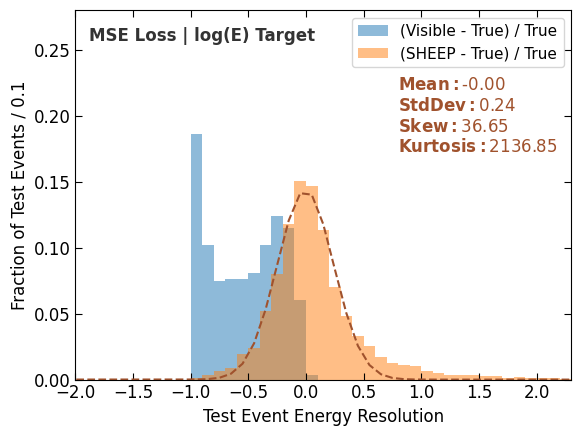

In [14]:
from scipy.optimize import curve_fit
def gaussian(x, amplitude, mean, std_dev):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2))


plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'legend.fontsize': 12})
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3

res_vis_true = (mse_log.ve - mse_log.labels) / mse_log.labels
res_true_pred = (mse_log.preds - mse_log.labels)/ mse_log.labels
rbins = np.linspace(-10, 10, 201)
num_events=len(res_vis_true)


hist_counts_vis_true, bin_edges_vis_true = np.histogram(res_vis_true, bins=rbins, density=False)
bin_centers_vis_true = (bin_edges_vis_true[:-1] + bin_edges_vis_true[1:]) / 2
initial_guesses_vis_true  = [np.max(hist_counts_vis_true), np.mean(res_vis_true), np.std(res_vis_true)]

hist_counts_true_pred, bin_edges_true_pred = np.histogram(res_true_pred, bins=rbins, density=False)
bin_centers_true_pred = (bin_edges_true_pred[:-1] + bin_edges_true_pred[1:]) / 2
initial_guesses_true_pred  = [np.max(hist_counts_true_pred/num_events), np.mean(res_true_pred), np.std(res_true_pred)]

# Perform the curve fit
vis_true_params, vis_true_covariance = curve_fit(gaussian, bin_centers_vis_true, hist_counts_vis_true, p0=initial_guesses_vis_true)
true_pred_params, true_pred_covariance = curve_fit(gaussian, bin_centers_true_pred, hist_counts_true_pred/num_events, p0=initial_guesses_true_pred)
true_pred_skew = skew(res_true_pred)
print("Skew:", true_pred_skew)
true_pred_kurtosis = kurtosis(res_true_pred)
print("Kurtosis:", true_pred_kurtosis)

plt.hist(bin_edges_vis_true[:-1], bins=bin_edges_vis_true, weights=hist_counts_vis_true/num_events, label="(Visible - True) / True", alpha=0.5, edgecolor="none")
#plt.plot(bin_centers_vis_true, gaussian(bin_centers_vis_true, *vis_true_params), color='blue', linestyle="--")
plt.hist(bin_edges_true_pred[:-1],bins=bin_edges_true_pred, weights=hist_counts_true_pred/num_events, label="(SHEEP - True) / True", alpha=0.5, edgecolor="none")
plt.plot(bin_centers_true_pred, gaussian(bin_centers_true_pred, *true_pred_params), color='sienna', linestyle="--")
plt.legend(fontsize=11)
plt.xlim(-2, 2.3)
plt.ylim(0,0.28)
plt.ylabel("Fraction of Test Events / 0.1")
plt.xlabel("Test Event Energy Resolution")
ax=plt.gca()
ax.text(0.8, 0.23, r"$\mathbf{Mean:}$"+f"{true_pred_params[1]:.2f}\n"+r"$\mathbf{Std Dev:}$"+f"{true_pred_params[2]:.2f}\n"+r"$\mathbf{Skew:}$"+f"{true_pred_skew:.2f}\n"+r"$\mathbf{Kurtosis:}$"+f"{true_pred_kurtosis:.2f}", fontsize=12, verticalalignment='top', color='sienna')
#ax.text(-1.88, 0.267, f"PRELIMINARY", fontsize=18, verticalalignment='top', color='black', alpha=0.35, fontweight='bold')
ax.text(-1.88, 0.267, mse_log.version, fontsize=12, verticalalignment='top', color='black', alpha=0.8, fontweight='bold')

/tmp/ipykernel_1323644/2208736617.py:40: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{ebins[i]:.0f}-{ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {true_pred_skew_by_ebin:.2f}\nKurtosis: {true_pred_kurtosis_by_ebin:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))


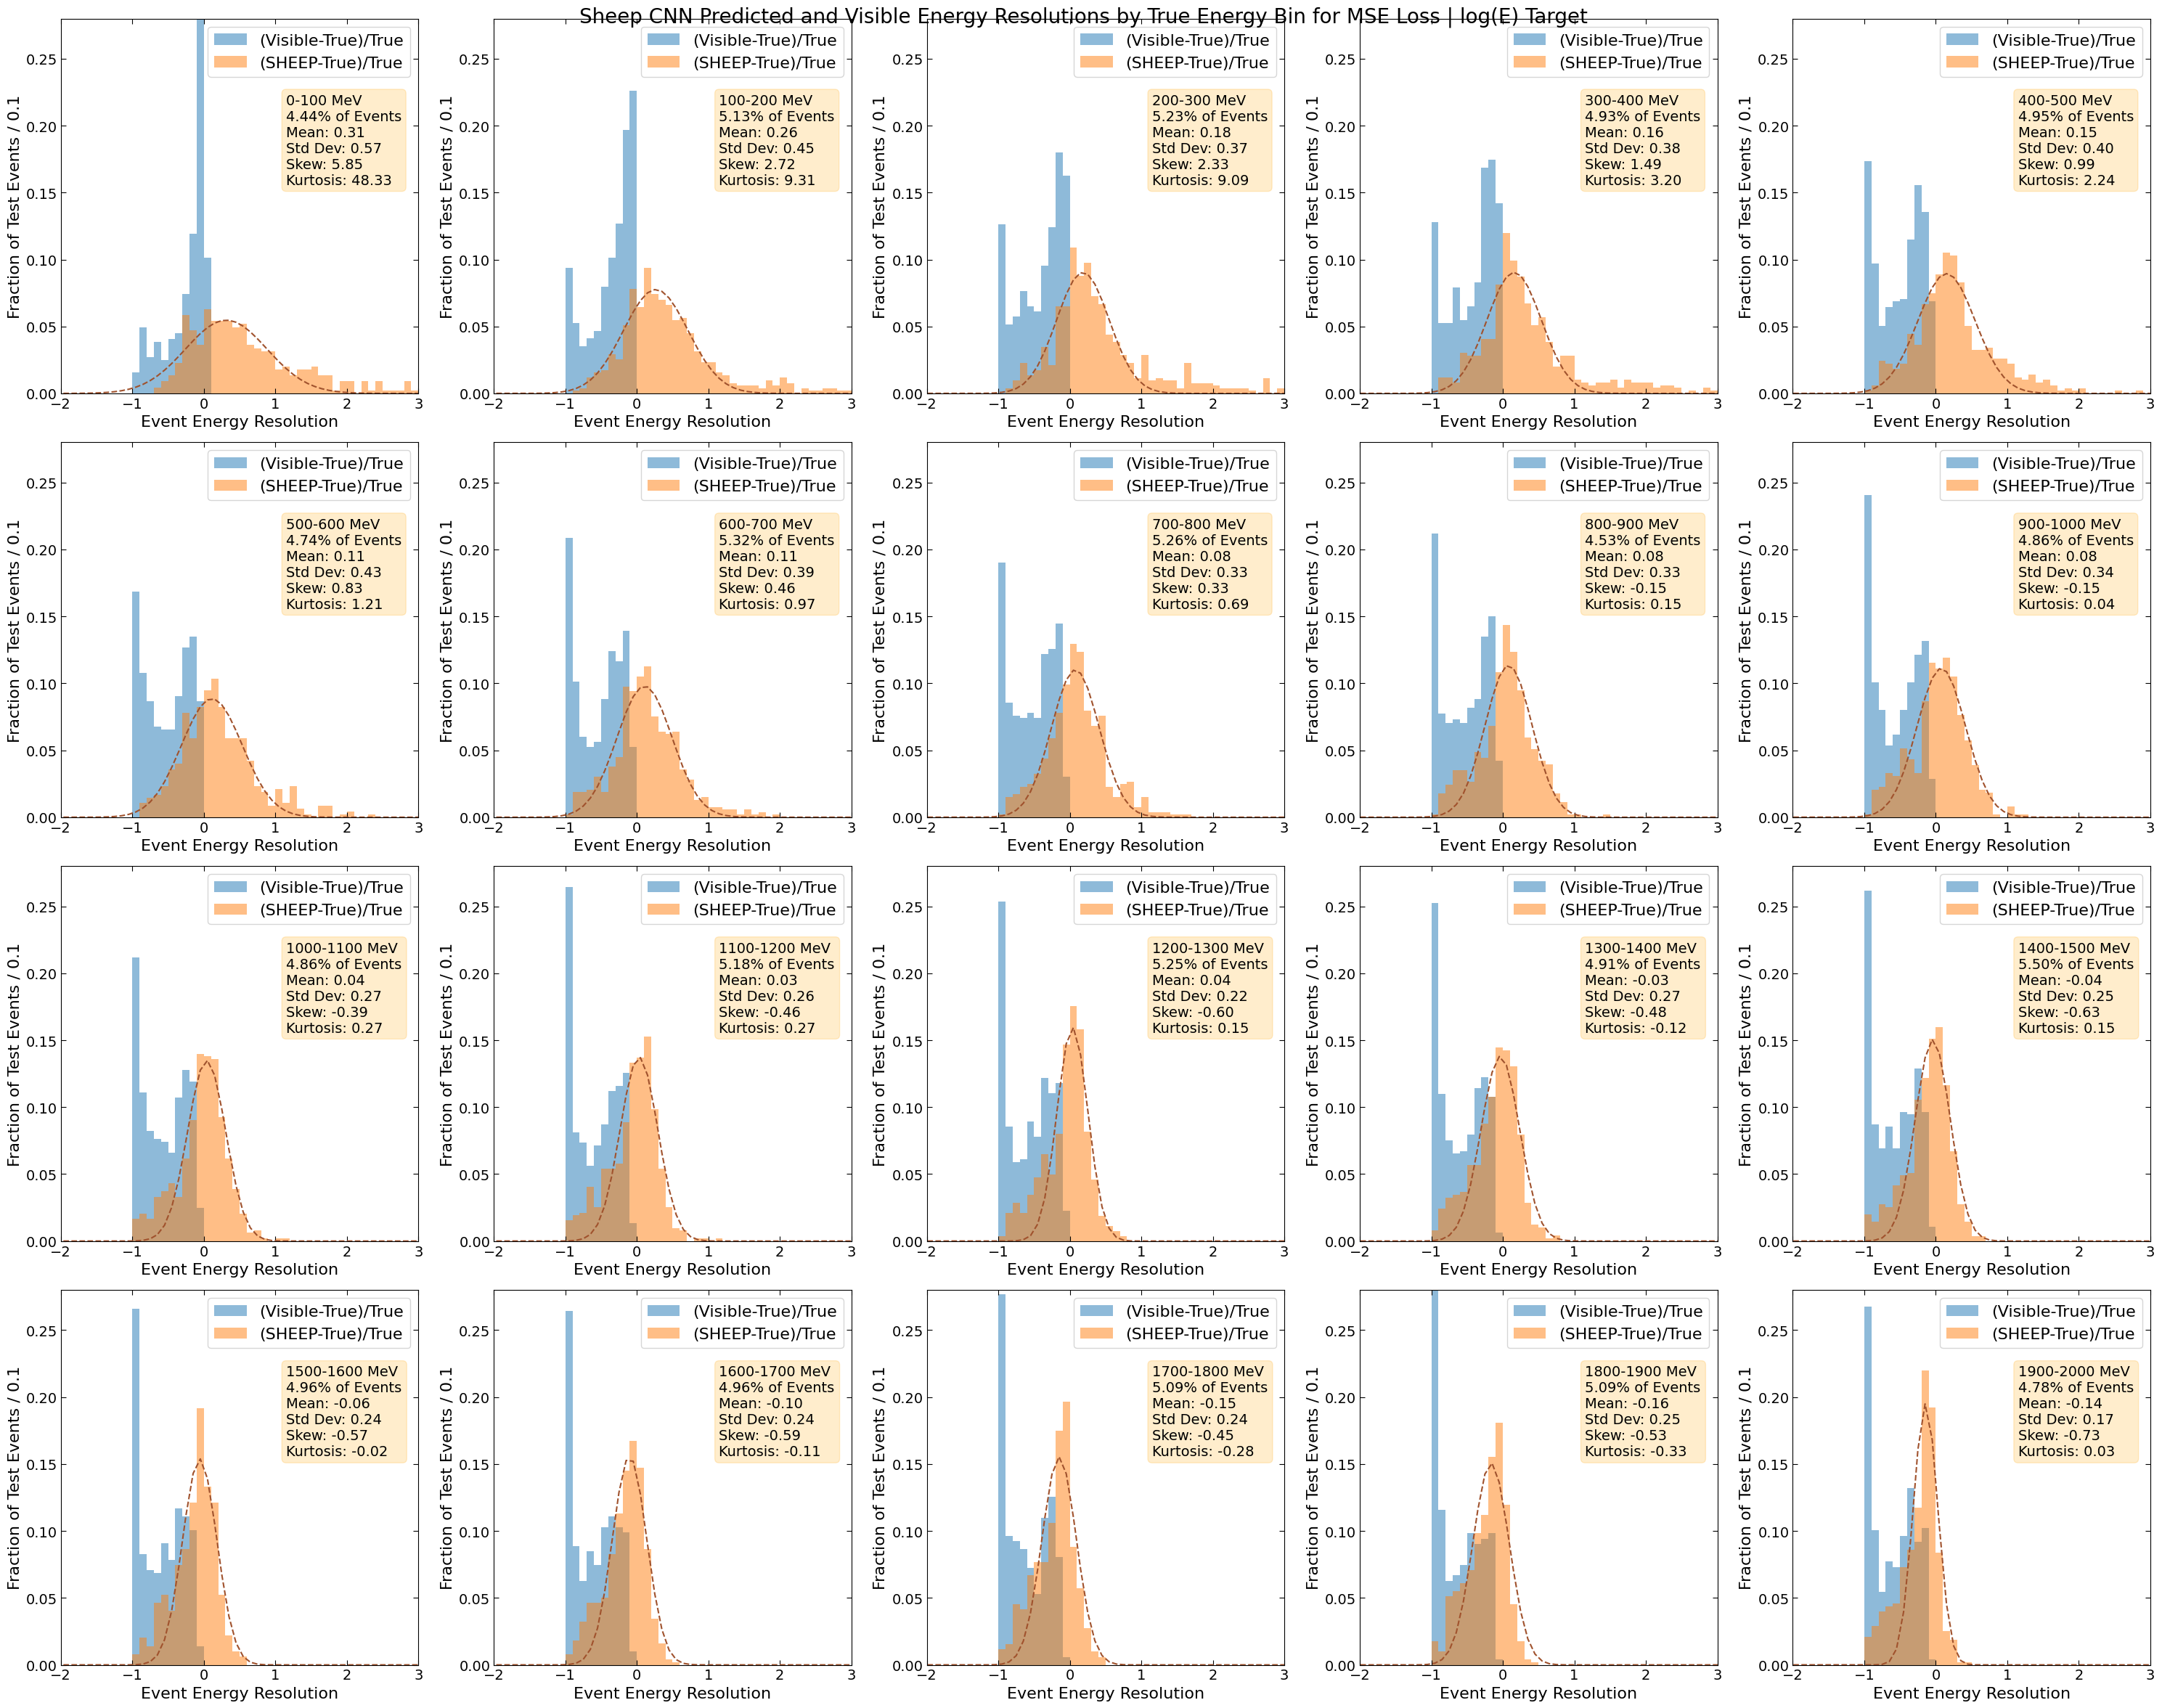

In [13]:
ebins = np.linspace(0, 2000, mse_log.num_energy_bins + 1)
ebin_centers = 0.5 * (ebins[:-1] + ebins[1:])
    
fig, ax = plt.subplots(int(mse_log.num_energy_bins/5),5, figsize=(30, int(6*(mse_log.num_energy_bins/5))))#, sharex=True, sharey=True)
ax = ax.flatten()
rbins = np.linspace(-10, 10, 201)
    
for i in range(mse_log.num_energy_bins):
    bin_mask = (mse_log.labels > ebins[i]) & (mse_log.labels <= ebins[i + 1])
    if np.sum(bin_mask) == 0:
        continue
    ve_bin = mse_log.ve[bin_mask]
    true_bin = mse_log.labels[bin_mask]
    pred_bin =  mse_log.preds[bin_mask]
    res_vis_true = (ve_bin-true_bin) / true_bin
    res_true_pred = (pred_bin-true_bin)/ true_bin
    num_events_per_energy_bin = len(true_bin)
    frac_events_per_energy_bin = (num_events_per_energy_bin/len(mse_log.labels))*100

    hist_counts_vis_true, bin_edges_vis_true = np.histogram(res_vis_true, bins=rbins, density=False)
    bin_centers_vis_true = (bin_edges_vis_true[:-1] + bin_edges_vis_true[1:]) / 2
    initial_guesses_vis_true  = [np.max(hist_counts_vis_true/num_events_per_energy_bin), np.mean(res_vis_true), np.std(res_vis_true)]

    hist_counts_true_pred, bin_edges_true_pred = np.histogram(res_true_pred, bins=rbins, density=False)
    bin_centers_true_pred = (bin_edges_true_pred[:-1] + bin_edges_true_pred[1:]) / 2
    initial_guesses_true_pred  = [np.max(hist_counts_true_pred/num_events_per_energy_bin), np.mean(res_true_pred), np.std(res_true_pred)]
    true_pred_params, true_pred_covariance = curve_fit(gaussian, bin_centers_true_pred, (hist_counts_true_pred/num_events_per_energy_bin), p0=initial_guesses_true_pred)
    true_pred_skew_by_ebin = skew(res_true_pred)
    true_pred_kurtosis_by_ebin = kurtosis(res_true_pred)
        
    ax[i].hist(bin_edges_vis_true[:-1], bins=rbins, weights=hist_counts_vis_true/num_events_per_energy_bin, label=f'(Visible-True)/True', alpha=0.5)
    ax[i].hist(bin_edges_true_pred[:-1], bins=rbins, weights=hist_counts_true_pred/num_events_per_energy_bin, label=f'(SHEEP-True)/True', alpha=0.5)
    ax[i].plot(bin_centers_true_pred, gaussian(bin_centers_true_pred, *true_pred_params), color='sienna', linestyle="--")
    ax[i].set_xlim(-2, 3)
    ax[i].set_ylim(-0, 0.28)
    ax[i].set_xlabel('Event Energy Resolution', fontsize=16)
    ax[i].set_ylabel('Fraction of Test Events / 0.1', fontsize=16)
    ax[i].legend(loc='upper right', fontsize=16)
    ax[i].tick_params(axis='both', which='major', labelsize=14)
    ax[i].text(0.63, 0.8, f"{ebins[i]:.0f}-{ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {true_pred_skew_by_ebin:.2f}\nKurtosis: {true_pred_kurtosis_by_ebin:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))

    ax[i].legend(loc='upper right', fontsize=16)
fig.suptitle(f'Sheep CNN Predicted and Visible Energy Resolutions by True Energy Bin for {mse_log.version}', size=20)
fig.tight_layout()
